(18405, 110)
   player_id                                player_url  fifa_version  \
0     252371    /player/252371/jude-bellingham/260004/            26   
1     239053  /player/239053/federico-valverde/260004/            26   
2     212622     /player/212622/joshua-kimmich/260004/            26   
3     235212      /player/235212/achraf-hakimi/260004/            26   
4     224232     /player/224232/nicolo-barella/260004/            26   

   fifa_update fifa_update_date     short_name  \
0            4       2025-09-19  J. Bellingham   
1            4       2025-09-19    F. Valverde   
2            4       2025-09-19     J. Kimmich   
3            4       2025-09-19      A. Hakimi   
4            4       2025-09-19     N. Barella   

                            long_name player_positions  overall  potential  \
0      Jude Victor William Bellingham          CAM, CM       90         94   
1  Federico Santiago Valverde Dipetta      CM, CDM, RB       89         90   
2               Jos

/var/folders/n_/pbsy2sfn2d5flxn82kbghpb80000gn/T/ipykernel_1705/1769789005.py:5: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/faiyazbinshafiq/Playground/ML/Projects/fc26_players_position_playing_style_prediction/data/FC26_20250921.csv")


,pace,shooting,passing,dribbling,physic
primary_position,,,,,
CAM,69.766931,61.465259,64.442392,68.692172,57.875989
CB,60.308479,36.110643,49.737222,52.755262,71.345159
CDM,62.117237,52.625960,61.839498,64.095604,68.729937
CM,65.939476,57.775971,63.586721,66.270551,63.978320
GK,NaN,NaN,NaN,NaN,NaN
LB,72.800293,46.159473,58.294075,63.275786,64.506218
LM,76.816729,60.690789,60.859023,68.089286,58.040414
LW,76.248731,61.324873,59.385787,67.637056,55.718274
RB,72.650738,45.620520,57.533380,62.807449,65.452565


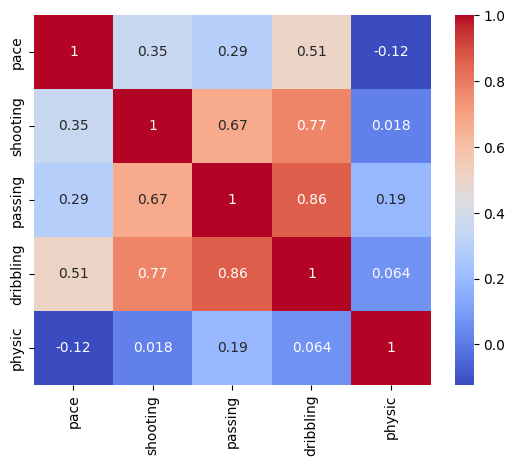

In [19]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/faiyazbinshafiq/Playground/ML/Projects/fc26_players_position_playing_style_prediction/data/FC26_20250921.csv")
print(df.shape)
df.columns.tolist()
print(df.head())

#Extracting the players primary position, since we only want one target label instead of several positions a player can play
df["primary_position"] = df["player_positions"].str.split(",").str[0].str.strip()

#Shows the number of players in each position
df["primary_position"].value_counts().plot(kind="bar")

#Missing values
df.isnull().sum().sort_values(ascending=False).head(20)

#Inspecting correlations
numeric_attrs = ["pace", "shooting", "passing", "dribbling","physic"]
sns.heatmap(df[numeric_attrs].corr(), annot=True, cmap="coolwarm")
plt.savefig("/Users/faiyazbinshafiq/Playground/ML/Projects/fc26_players_position_playing_style_prediction/reports/figures/attributes_correlation.png")

df.groupby("primary_position")[numeric_attrs].mean()